# Evaluation pipeline for Smoking Dataset
 optimal GAN hyperparams:{'epochs':30, 'lr': 0.0001, 'hidden_dim': 32, 'l1_weight': 10.0, 'batch_size': 32}

In [ ]:
import os
import numpy as np
import copy
import random
from typing import Any
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# XGBoost import (install xgboost if not present)
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    print("XGBoost not installed, skipping XGBoost comparison.")
    xgb_available = False

# ==========================================
# 1. GAN Classes & Training Function
# ==========================================

class MLPGenerator(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=1):
        super(MLPGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.Linear(hidden_dim // 2, output_dim)
        )
    def forward(self, x): return self.net(x)

class MLPDiscriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(MLPDiscriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim // 2, 1)
        )
    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=1))

def train_tabular_gan(epochs, fixed_params, X_train, y_train, X_val, y_val, device):
    """
    Trains the GAN for a specific number of epochs and returns the Validation MSE, predictions and true values.
    """
    # Unpack fixed parameters
    lr = fixed_params['lr']
    hidden_dim = fixed_params['hidden_dim']
    l1_weight = fixed_params['l1_weight']
    batch_size = fixed_params['batch_size']

    # --- Data Prep ---
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    
    # Scale inputs
    X_train_s = scaler_x.fit_transform(X_train)
    y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1))
    
    dataset = TensorDataset(torch.FloatTensor(X_train_s).to(device), 
                            torch.FloatTensor(y_train_s).to(device))
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # --- Initialize Models ---
    input_dim = X_train.shape[1]
    G = MLPGenerator(input_dim, hidden_dim).to(device)
    D = MLPDiscriminator(input_dim + 1, hidden_dim).to(device)
    
    opt_G = optim.Adam(G.parameters(), lr=lr)
    opt_D = optim.Adam(D.parameters(), lr=lr)
    
    crit_gan = nn.BCEWithLogitsLoss()
    crit_l1 = nn.L1Loss()

    # --- Training Loop ---
    G.train()
    for _ in range(epochs):
        for x_batch, y_batch in dataloader:
            # 1. Train Discriminator
            opt_D.zero_grad()
            valid = torch.ones(x_batch.size(0), 1).to(device)
            fake_zeros = torch.zeros(x_batch.size(0), 1).to(device)
            
            # Real loss
            pred_real = D(x_batch, y_batch)
            loss_real = crit_gan(pred_real, valid)
            
            # Fake loss
            fake_target = G(x_batch)
            pred_fake = D(x_batch, fake_target.detach())
            loss_fake = crit_gan(pred_fake, fake_zeros)
            
            loss_d = (loss_real + loss_fake) / 2
            loss_d.backward()
            opt_D.step()

            # 2. Train Generator
            opt_G.zero_grad()
            # Fool D
            pred_fake_g = D(x_batch, fake_target)
            loss_gan_g = crit_gan(pred_fake_g, valid)
            # Match Truth
            loss_l1 = crit_l1(fake_target, y_batch)
            
            loss_g = loss_gan_g + (l1_weight * loss_l1)
            loss_g.backward()
            opt_G.step()

    # --- Evaluation ---
    G.eval()
    X_val_s = torch.FloatTensor(scaler_x.transform(X_val)).to(device)
    with torch.no_grad():
        preds_s = G(X_val_s).cpu().numpy()
    
    preds = scaler_y.inverse_transform(preds_s)
    mse = mean_squared_error(y_val, preds)
    return mse, preds, y_val

# ==========================================
# 2. Pipeline Setup
# ==========================================

# TODO: use full dataset after testing pipeline
cleaned_adherence_data = np.load("smoking_data_for_ML.npy")
cleaned_adherence_data = cleaned_adherence_data[:,:,:]
np.set_printoptions(threshold=np.inf)

# Optionally choose/print working directory before loading datasets
cwd = os.getcwd()
print(f"Current working directory: {cwd}")
# os.chdir('/Users/andreilixandru/Downloads/NDEs-for-adherence-main')

from clean_ndes import create_reinforce_dataset, get_reinforce_config, AdherencePredictor, train_one_epoch
from clean_ndes.data_utils import classes_to_values
from clean_ndes.datasets import AdherenceDataset

torch.manual_seed(0) # torch seed for reproducibility

# TODO: pick runs
N_RUNS = 3
seeds = [torch.randint(0, 1000000, size=(1,)).item() for _ in range(N_RUNS)]
# with open("/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_many_baselines/seeds.pkl", "wb") as f:
#     pickle.dump(seeds, f)

N_EPOCHS = 5
TRAIN_SPLIT = 0.8
BATCH_SIZE_VALUE = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

reinforce_data = cleaned_adherence_data
dataset = AdherenceDataset(reinforce_data, target_as_classes=True)

dataset_size = len(dataset)
train_size = int(TRAIN_SPLIT * dataset_size)
val_size = dataset_size - train_size

print("train_size", train_size)
print("val_size", val_size)

train_losses_acrossRuns= []
# NDE evaluation MSEs per run (exclude timestep 0)
nde_mses_acrossRuns = []
# llm_mses_acrossRuns = []

val_sets_acrossRuns = []
ndes_acrossRuns = []

# ------------ for baseline algorithms -----------------------
N = reinforce_data.shape[0]
T = reinforce_data.shape[1]
D = reinforce_data.shape[2]

# Define models and their hyperparameter grids for tuning
model_configs = [
    {
        "name": "Linear Regression",
        "estimator": LinearRegression(),
        "param_grid": {} 
    },
    {
        "name": "Ridge Regression",
        "estimator": Ridge(),
        "param_grid": {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}
    },
    {
        "name": "Lasso Regression",
        "estimator": Lasso(max_iter=10000),
        "param_grid": {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}
    },
    {
        "name": "Random Forest",
        "estimator": RandomForestRegressor(random_state=42, n_jobs=-1),
        "param_grid": {
            "n_estimators": [50, 100],
            "max_depth": [3, 5, 10, None]
        }
    }
]
if xgb_available:
    model_configs.append({
        "name": "XGBoost",
        "estimator": XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        "param_grid": {
            "n_estimators": [50, 100],
            "max_depth": [3, 5, 10],
            "learning_rate": [0.01, 0.1, 0.3]
        }
    })

# Store results for each model
results = {
    cfg["name"]: {
        "mse_model_list": [],
        "mse_baseline_list": [],
        "best_params_list": []
    }
    for cfg in model_configs
}

# Add Majority Class baseline
results["Majority Class"] = {
    "mse_model_list": [],
    "mse_baseline_list": [],
    "best_params_list": []
}

# --- ADD TABULAR GAN TO RESULTS ---
results["Tabular GAN"] = {
    "mse_model_list": [],
    "mse_baseline_list": [],
    "best_params_list": []
}

#-------------------------------------------------
previous_train_set = []
for run_idx in range(N_RUNS):
    print(f"========= Run {run_idx+1} ============")
    random_seed = seeds[run_idx]
    train_set, val_set = random_split(
        dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(random_seed)
    )
    previous_train_set = train_set

    val_sets_acrossRuns.append(val_set)

    # ------------------ train Baseline algorithms ------------------
    X_train = np.array(train_set[:][0]).reshape(-1, D-1)
    y_train = np.array(train_set[:][1]).reshape(-1).astype(float)
    # excluding first timepoint in test trajectories
    X_test = np.array(val_set[:][0][:,1:]).reshape(-1, D-1)
    y_test = np.array(val_set[:][1][:,1:]).reshape(-1).astype(float)

    mean_pred = np.full_like(y_test, fill_value=np.mean(y_train))
    mse_mean = mean_squared_error(y_test, mean_pred)
    with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_smoking_many_baselines/RUNS_mean/pred_run_{run_idx+1}.pkl", "wb") as f:
        pickle.dump(mean_pred, f) 

        # ------------------ Majority Class Baseline ------------------
    y_train_classes = np.array(train_set[:][1]).reshape(-1).astype(int)
    unique_classes, class_counts = np.unique(y_train_classes, return_counts=True)
    majority_class = unique_classes[np.argmax(class_counts)]
    y_test_classes = np.array(val_set[:][1][:,1:]).reshape(-1).astype(int)
    y_pred_majority_class = np.full_like(y_test_classes, fill_value=majority_class)
    
    mse_majority_class = mean_squared_error(y_test_classes, y_pred_majority_class)
    baseline_pred = np.full_like(y_test_classes, fill_value=np.mean(y_train_classes))
    mse_baseline = mean_squared_error(y_test_classes, baseline_pred)
    
    with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_smoking_many_baselines/RUNS_majority_class/pred_run_{run_idx+1}.pkl", "wb") as f:
      pickle.dump(y_pred_majority_class, f) 

    for model_cfg in model_configs:
        model_name = model_cfg["name"]

        # Hyperparameter tuning if grid is not empty
        if model_cfg["param_grid"]:
            grid = GridSearchCV(
                model_cfg["estimator"],
                model_cfg["param_grid"],
                scoring="neg_mean_squared_error",
                cv=3,
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            reg = grid.best_estimator_
            best_params = grid.best_params_
        else:
            reg = model_cfg["estimator"]
            reg.fit(X_train, y_train)
            best_params = {}

        y_pred = reg.predict(X_test)
        mse_model = mean_squared_error(y_test, y_pred)
        baseline_pred = np.full_like(y_test, fill_value=np.mean(y_train))
        mse_baseline = mean_squared_error(y_test, baseline_pred)
        with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_many_baselines/RUNS_{model_name}/pred_run_{run_idx+1}.pkl", "wb") as f:
            pickle.dump(y_pred, f) 
        with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_many_baselines/RUNS_{model_name}/true_run_{run_idx+1}.pkl", "wb") as f:
            pickle.dump(y_test, f)


        results[model_name]["mse_model_list"].append(mse_model)
        results[model_name]["mse_baseline_list"].append(mse_baseline)
        results[model_name]["best_params_list"].append(best_params)



    # ------------------ Majority Class Baseline ------------------
    y_train_classes = np.array(train_set[:][1]).reshape(-1).astype(int)
    unique_classes, class_counts = np.unique(y_train_classes, return_counts=True)
    majority_class = unique_classes[np.argmax(class_counts)]
    y_test_classes = np.array(val_set[:][1][:,1:]).reshape(-1).astype(int)
    y_pred_majority_class = np.full_like(y_test_classes, fill_value=majority_class)
    
    mse_majority_class = mean_squared_error(y_test_classes, y_pred_majority_class)
    baseline_pred = np.full_like(y_test_classes, fill_value=np.mean(y_train_classes))
    mse_baseline = mean_squared_error(y_test_classes, baseline_pred)
    
    with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_many_baselines/RUNS_majority_class/pred_run_{run_idx+1}.pkl", "wb") as f:
      pickle.dump(y_pred_majority_class, f) 
    with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_many_baselines/RUNS_majority_class/true_run_{run_idx+1}.pkl", "wb") as f:
      pickle.dump(y_test_classes, f)
    
    results["Majority Class"]["mse_model_list"].append(mse_majority_class)
    results["Majority Class"]["mse_baseline_list"].append(mse_baseline)
    results["Majority Class"]["best_params_list"].append({})

    # ------------------ Train Tabular GAN ------------------
    # Fixed Hyperparameters provided
    gan_fixed_params = {'lr': 0.0001, 'hidden_dim': 32, 'l1_weight': 10.0, 'batch_size': 32}
    gan_epochs = 30
    
    mse_gan, y_pred_gan, y_true_gan = train_tabular_gan(
        epochs=gan_epochs,
        fixed_params=gan_fixed_params,
        X_train=X_train,
        y_train=y_train,
        X_val=X_test,
        y_val=y_test,
        device=DEVICE
    )
    
    baseline_pred_gan = np.full_like(y_test, fill_value=np.mean(y_train))
    mse_baseline_gan = mean_squared_error(y_test, baseline_pred_gan)
    with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_many_baselines/RUNS_GAN/pred_run_{run_idx+1}.pkl", "wb") as f:
      pickle.dump(y_pred_gan, f) 
    with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_many_baselines/RUNS_GAN/true_run_{run_idx+1}.pkl", "wb") as f:
      pickle.dump(y_true_gan, f)

    results["Tabular GAN"]["mse_model_list"].append(mse_gan)
    results["Tabular GAN"]["mse_baseline_list"].append(mse_baseline_gan)
    results["Tabular GAN"]["best_params_list"].append(gan_fixed_params)

    # ------------------ train NDE ------------------
    data_raw = cleaned_adherence_data
    config = get_reinforce_config(data_raw, n_classes=11) 
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE_VALUE, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE_VALUE, shuffle=False)

    model = AdherencePredictor(in_dim=config['input_dim'], out_dim=config['output_dim'])
    ndes_acrossRuns.append(copy.deepcopy(model))

    train_losses_acrossEpochs = []

    for epoch in range(N_EPOCHS):
        train_lossesThisBarch, _ = train_one_epoch(model, train_loader, val_loader)
        train_losses_acrossEpochs.extend(train_lossesThisBarch)
    train_losses_acrossRuns.append(train_losses_acrossEpochs)

    # ------------------ NDE evaluation ------------------
    model.eval()
    y_true_nde = []
    y_pred_nde = []

    with torch.no_grad():
        for val_idx in range(len(val_set)):
            true_traj = val_set[val_idx][1]
            X_patient, Y_patient = val_set[val_idx][0], val_set[val_idx][1]
            T_patient = len(true_traj)
            predicted_adherence = torch.zeros(T_patient, dtype=torch.long)
            predicted_adherence[0] = Y_patient[0]

            current_y = torch.cat([Y_patient[0].float().unsqueeze(0), X_patient[0]])
            for t in range(1, T_patient):
                pred_next = model.inference(current_y)
                predicted_adherence[t] = pred_next
                if t < T_patient:
                    current_y = torch.cat([Y_patient[t].float().unsqueeze(0), X_patient[t]])

            pred_nde = predicted_adherence.cpu().numpy()
            y_true_nde.append(true_traj[1:])
            y_pred_nde.append(pred_nde[1:])

    y_true_nde = np.concatenate(y_true_nde)
    y_pred_nde = np.concatenate(y_pred_nde)
    mse_nde_run = mean_squared_error(y_true_nde, y_pred_nde)
    nde_mses_acrossRuns.append(mse_nde_run)

    with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_many_baselines/RUNS_NDE/pred_run_{run_idx+1}.pkl", "wb") as f:
      pickle.dump(y_pred_nde, f) 
    with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_many_baselines/RUNS_NDE/true_run_{run_idx+1}.pkl", "wb") as f:
      pickle.dump(y_true_nde, f)


# ==========================================
# 3. Final Reporting
# ==========================================

# Aggregating results
methods = [cfg["name"] for cfg in model_configs] + ["Majority Class", "Tabular GAN", "Baseline"]

# Calculate aggregate stats
means = [np.mean(results[m]["mse_model_list"]) for m in methods if m != "Baseline"]
stds = [np.std(results[m]["mse_model_list"]) for m in methods if m != "Baseline"]
mins = [np.min(results[m]["mse_model_list"]) for m in methods if m != "Baseline"]
maxs = [np.max(results[m]["mse_model_list"]) for m in methods if m != "Baseline"]

# For baseline, just pick the first one available
baseline_mses = list[dict[str, list]](results.values())[0]["mse_baseline_list"]
baseline_means = np.mean(baseline_mses)
baseline_stds = np.std(baseline_mses)
baseline_mins = np.min(baseline_mses)
baseline_maxs = np.max(baseline_mses)


means.append(baseline_means)
stds.append(baseline_stds)
mins.append(baseline_mins)
maxs.append(baseline_maxs)

# NDE stats
methods.append("NDE")
nde_mses = np.array(nde_mses_acrossRuns)
nde_mean = np.mean(nde_mses)
nde_std  = np.std(nde_mses)
nde_min  = np.min(nde_mses)
nde_max  = np.max(nde_mses)
means.append(nde_mean)
stds.append(nde_std)
mins.append(nde_min)
maxs.append(nde_max)

# # LLM stats (Handling empty list case)
# methods.append("LLM")
# if len(llm_mses_acrossRuns) > 0:
#     llm_mses = np.array(llm_mses_acrossRuns)
#     llm_mean = np.mean(llm_mses)
#     llm_std  = np.std(llm_mses)
#     llm_min  = np.min(llm_mses)
#     llm_max  = np.max(llm_mses)
# else:
#     llm_mean = llm_std = llm_min = llm_max = np.nan

# means.append(llm_mean)
# stds.append(llm_std)
# mins.append(llm_min)
# maxs.append(llm_max)

# Print Final Table
print("\n" + "="*80)
print(f"{'Method':<20} | {'Mean MSE':<10} | {'Std Dev':<10} | {'Min MSE':<10} | {'Max MSE':<10}")
print("-" * 80)
for i, method in enumerate(methods):
    print(f"{method:<20} | {means[i]:<10.4f} | {stds[i]:<10.4f} | {mins[i]:<10.4f} | {maxs[i]:<10.4f}")
print("="*80 + "\n")

XGBoost not installed, skipping XGBoost comparison.
Current working directory: /Users/andreilixandru/Downloads/NDEs-for-adherence-main
train_size 399
val_size 100
========= Run 1 ============
========= Run 2 ============
========= Run 3 ============


/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_3439/668295772.py:262: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_train = np.array(train_set[:][0]).reshape(-1, D-1)
/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_3439/668295772.py:263: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_train = np.array(train_set[:][1]).reshape(-1).astype(float)
/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_3439/668295772.py:265: DeprecationWarning: __arr

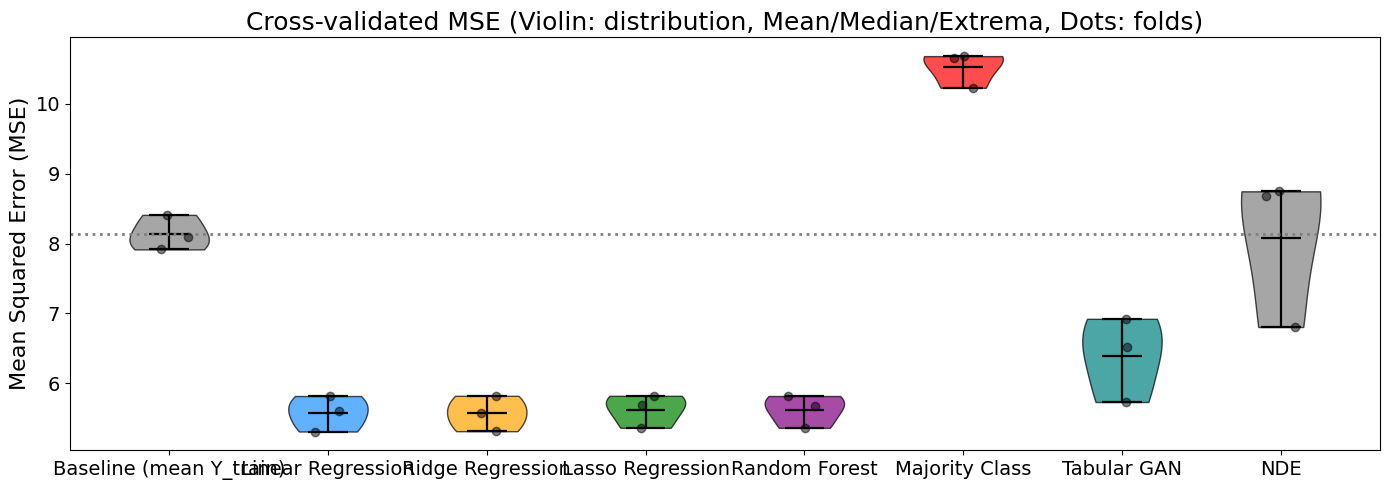

In [6]:
import matplotlib.pyplot as plt

# Set up wider figure
fig, ax = plt.subplots(figsize=(14, 5))

# Update Baseline label for xticks
methods_for_xticks = [m if m != "Baseline" else "Baseline (mean Y_train)" for m in methods]

# ---- Reorder so that Baseline is first ----
# Find the index for Baseline
baseline_idx = methods.index("Baseline")

# Prepare tuples of all data
bars_data = list(zip(
    methods,
    methods_for_xticks,
    means,
    stds,
    mins,
    maxs
))

# Move Baseline to the front
bars_data = [bars_data[baseline_idx]] + bars_data[:baseline_idx] + bars_data[baseline_idx+1:]

# Unpack
ordered_methods, ordered_methods_for_xticks, ordered_means, ordered_stds, ordered_mins, ordered_maxs = zip(*bars_data)

# For NDE and Baseline, adjust the mse_lists
mse_list_map = {}
for m in ordered_methods:
    if m == "NDE":
        mse_list_map[m] = nde_mses
    elif m == "Baseline":
        mse_list_map[m] = baseline_mses
    else:
        mse_list_map[m] = results[m]["mse_model_list"]

# Collect data for violin plot: Each element is a list of MSEs for each method in order
mse_lists_ordered = [mse_list_map[m] for m in ordered_methods]

# Violin plot
parts = ax.violinplot(
    mse_lists_ordered,
    positions=np.arange(len(ordered_methods_for_xticks)),
    showmeans=True,
    showmedians=False,
    showextrema=True
)

# Custom coloring for violins (optional; can remove for default look)
violin_colors = ['gray', 'dodgerblue', 'orange', 'green', 'purple', 'red', 'teal']
for i, pc in enumerate(parts['bodies']):
    color = violin_colors[i % len(violin_colors)]
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')

for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    vp = parts.get(partname)
    if vp is not None:
        vp.set_edgecolor('black')
        vp.set_linewidth(1.6)

# Jitter scatter points for each method
for i, mse_list in enumerate(mse_lists_ordered):
    xvals = np.random.normal(loc=i, scale=0.05, size=len(mse_list))
    ax.scatter(xvals ,mse_list, color='k', alpha=0.5, zorder=10, label='_nolegend_')

# Draw horizontal line at baseline mean
ax.axhline(baseline_means, color='gray', linestyle=':', linewidth=2, label='Baseline Mean')

# Labeling
ax.set_ylabel("Mean Squared Error (MSE)", fontsize=16)
ax.set_title("Cross-validated MSE (Violin: distribution, Mean/Median/Extrema, Dots: folds)", fontsize=18)
ax.set_xticks(np.arange(len(ordered_methods_for_xticks)))
ax.set_xticklabels(ordered_methods_for_xticks, fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend().set_visible(False)
plt.tight_layout()
plt.show()

# Same on Reinforce data

In [28]:
import os
import numpy as np
import copy
import random
from typing import Any
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Set print options
np.set_printoptions(threshold=np.inf)

# 1. Load Data FIRST so we have 'reinforce_data' available
reinforce_data = np.load("reinforce_preprocessed_withDemographics.npy")

# Set working directory (adjust if necessary)
os.chdir('/Users/andreilixandru/Downloads/NDEs-for-adherence-main')

from clean_ndes import create_reinforce_dataset, get_reinforce_config, AdherencePredictor, train_one_epoch
from clean_ndes.data_utils import classes_to_values
from clean_ndes.datasets import AdherenceDataset

# XGBoost import
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False

# ==========================================
# 2. GAN Classes & Logic
# ==========================================

class MLPGenerator(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=1):
        super(MLPGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.Linear(hidden_dim // 2, output_dim)
        )
    def forward(self, x): return self.net(x)

class MLPDiscriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(MLPDiscriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim // 2, 1)
        )
    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=1))

def train_tabular_gan(epochs, fixed_params, X_train, y_train, X_val, y_val, device):
    """
    Trains the GAN for a specific number of epochs and returns the Validation MSE.
    """
    # Unpack params
    lr = fixed_params['lr']
    hidden_dim = fixed_params['hidden_dim']
    l1_weight = fixed_params['l1_weight']
    batch_size = fixed_params['batch_size']

    # Scale inputs
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    
    X_train_s = scaler_x.fit_transform(X_train)
    y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1))
    
    dataset = TensorDataset(torch.FloatTensor(X_train_s).to(device), 
                            torch.FloatTensor(y_train_s).to(device))
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Initialize Models
    input_dim = X_train.shape[1]
    G = MLPGenerator(input_dim, hidden_dim).to(device)
    D = MLPDiscriminator(input_dim + 1, hidden_dim).to(device)
    
    opt_G = optim.Adam(G.parameters(), lr=lr)
    opt_D = optim.Adam(D.parameters(), lr=lr)
    
    crit_gan = nn.BCEWithLogitsLoss()
    crit_l1 = nn.L1Loss()

    # Training Loop
    G.train()
    for _ in range(epochs):
        for x_batch, y_batch in dataloader:
            # Train Discriminator
            opt_D.zero_grad()
            valid = torch.ones(x_batch.size(0), 1).to(device)
            fake_zeros = torch.zeros(x_batch.size(0), 1).to(device)
            
            fake_target = G(x_batch)
            
            # Real & Fake Loss
            loss_real = crit_gan(D(x_batch, y_batch), valid)
            loss_fake = crit_gan(D(x_batch, fake_target.detach()), fake_zeros)
            
            loss_d = (loss_real + loss_fake) / 2
            loss_d.backward()
            opt_D.step()

            # Train Generator
            opt_G.zero_grad()
            pred_fake_g = D(x_batch, fake_target)
            loss_gan_g = crit_gan(pred_fake_g, valid)
            loss_l1 = crit_l1(fake_target, y_batch)
            
            loss_g = loss_gan_g + (l1_weight * loss_l1)
            loss_g.backward()
            opt_G.step()

    # Evaluation
    G.eval()
    X_val_s = torch.FloatTensor(scaler_x.transform(X_val)).to(device)
    with torch.no_grad():
        preds_s = G(X_val_s).cpu().numpy()
    
    preds = scaler_y.inverse_transform(preds_s)
    mse = mean_squared_error(y_val, preds)
    return mse

# ==========================================
# 3. Main Execution Pipeline
# ==========================================

torch.manual_seed(0)

# TODO: pick number of runs
N_RUNS = 10
seeds = [torch.randint(0, 1000000, size=(1,)).item() for _ in range(N_RUNS)]

N_EPOCHS = 5
TRAIN_SPLIT = 0.8
BATCH_SIZE_VALUE = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = AdherenceDataset(reinforce_data, target_as_classes=True)

dataset_size = len(dataset)
train_size = int(TRAIN_SPLIT * dataset_size)
val_size = dataset_size - train_size

train_losses_acrossRuns = []
nde_mses_acrossRuns = []
val_sets_acrossRuns = []
ndes_acrossRuns = []

N = reinforce_data.shape[0]
T = reinforce_data.shape[1]
D = reinforce_data.shape[2]

model_configs = [
    {
        "name": "Linear Regression",
        "estimator": LinearRegression(),
        "param_grid": {}
    },
    {
        "name": "Ridge Regression",
        "estimator": Ridge(),
        "param_grid": {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}
    },
    {
        "name": "Lasso Regression",
        "estimator": Lasso(max_iter=10000),
        "param_grid": {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}
    },
    {
        "name": "Random Forest",
        "estimator": RandomForestRegressor(random_state=42, n_jobs=-1),
        "param_grid": {
            "n_estimators": [50, 100],
            "max_depth": [3, 5, 10, None]
        }
    }
]
if xgb_available:
    model_configs.append({
        "name": "XGBoost",
        "estimator": XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        "param_grid": {
            "n_estimators": [50, 100],
            "max_depth": [3, 5, 10],
            "learning_rate": [0.01, 0.1, 0.3]
        }
    })

results = {
    cfg["name"]: {
        "mse_model_list": [],
        "mse_baseline_list": [],
        "best_params_list": []
    }
    for cfg in model_configs
}
results["Majority Class"] = {
    "mse_model_list": [],
    "mse_baseline_list": [],
    "best_params_list": []
}

# Add GAN to results dictionary
results["Tabular GAN"] = {
    "mse_model_list": [],
    "mse_baseline_list": [],
    "best_params_list": []
}

previous_train_set = []

for run_idx in range(N_RUNS):
    print(f"========= Run {run_idx+1}/{N_RUNS} ============")
    random_seed = seeds[run_idx]
    train_set, val_set = random_split(
        dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(random_seed)
    )
    previous_train_set = train_set
    val_sets_acrossRuns.append(val_set)

    # Baseline algorithms
    X_train = np.array(train_set[:][0]).reshape(-1, D-1)
    y_train = np.array(train_set[:][1]).reshape(-1).astype(float)
    X_test = np.array(val_set[:][0][:, 1:]).reshape(-1, D-1)
    y_test = np.array(val_set[:][1][:, 1:]).reshape(-1).astype(float)

    for model_cfg in model_configs:
        model_name = model_cfg["name"]
        if model_cfg["param_grid"]:
            grid = GridSearchCV(
                model_cfg["estimator"],
                model_cfg["param_grid"],
                scoring="neg_mean_squared_error",
                cv=3,
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            reg = grid.best_estimator_
            best_params = grid.best_params_
        else:
            reg = model_cfg["estimator"]
            reg.fit(X_train, y_train)
            best_params = {}
        y_pred = reg.predict(X_test)
        mse_model = mean_squared_error(y_test, y_pred)
        baseline_pred = np.full_like(y_test, fill_value=np.mean(y_train))
        mse_baseline = mean_squared_error(y_test, baseline_pred)
        results[model_name]["mse_model_list"].append(mse_model)
        results[model_name]["mse_baseline_list"].append(mse_baseline)
        results[model_name]["best_params_list"].append(best_params)

    # Majority Class baseline
    y_train_classes = np.array(train_set[:][1]).reshape(-1).astype(int)
    unique_classes, class_counts = np.unique(y_train_classes, return_counts=True)
    majority_class = unique_classes[np.argmax(class_counts)]
    y_test_classes = np.array(val_set[:][1][:, 1:]).reshape(-1).astype(int)
    y_pred_majority_class = np.full_like(y_test_classes, fill_value=majority_class)
    y_test_values = y_test_classes
    y_pred_majority_values = y_pred_majority_class
    y_train_values = y_train_classes
    mse_majority_class = mean_squared_error(y_test_values, y_pred_majority_values)
    baseline_pred = np.full_like(y_test_values, fill_value=np.mean(y_train_values))
    mse_baseline = mean_squared_error(y_test_values, baseline_pred)
    results["Majority Class"]["mse_model_list"].append(mse_majority_class)
    results["Majority Class"]["mse_baseline_list"].append(mse_baseline)
    results["Majority Class"]["best_params_list"].append({})

    # 3. Train Tabular GAN
    gan_params = {'epochs':30, 'lr': 0.0001, 'hidden_dim': 32, 'l1_weight': 10.0, 'batch_size': 32}
    
    gan_mse = train_tabular_gan(
        epochs=gan_params['epochs'],
        fixed_params=gan_params,
        X_train=X_train,
        y_train=y_train,
        X_val=X_test,
        y_val=y_test,
        device=DEVICE
    )
    
    # Store GAN results
    results["Tabular GAN"]["mse_model_list"].append(gan_mse)
    # Baseline for GAN is same as regression (Mean predictor)
    results["Tabular GAN"]["mse_baseline_list"].append(
        mean_squared_error(y_test, np.full_like(y_test, np.mean(y_train)))
    )
    results["Tabular GAN"]["best_params_list"].append(gan_params)

    # NDE training and evaluation
    data_raw = reinforce_data
    config = get_reinforce_config(data_raw)
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE_VALUE, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE_VALUE, shuffle=False)
    model = AdherencePredictor(in_dim=config['input_dim'], out_dim=config['output_dim'])
    ndes_acrossRuns.append(copy.deepcopy(model))
    train_losses_acrossEpochs = []
    for epoch in range(N_EPOCHS):
        train_lossesThisBarch, _ = train_one_epoch(model, train_loader, val_loader)
        train_losses_acrossEpochs.extend(train_lossesThisBarch)
    train_losses_acrossRuns.append(train_losses_acrossEpochs)

    model.eval()
    y_true_nde = []
    y_pred_nde = []
    with torch.no_grad():
        for val_idx in range(len(val_set)):
            true_traj = val_set[val_idx][1]
            X_patient, Y_patient = val_set[val_idx][0], val_set[val_idx][1]
            T_patient = len(true_traj)
            predicted_adherence = torch.zeros(T_patient, dtype=torch.long)
            predicted_adherence[0] = Y_patient[0]
            current_y = torch.cat([Y_patient[0].float().unsqueeze(0), X_patient[0]])
            for t in range(1, T_patient):
                pred_next = model.inference(current_y)
                predicted_adherence[t] = pred_next
                if t < T_patient:
                    current_y = torch.cat([Y_patient[t].float().unsqueeze(0), X_patient[t]])
            pred_nde = classes_to_values(predicted_adherence.cpu().numpy())  # map classes to values
            y_true_nde.append(true_traj[1:])
            y_pred_nde.append(pred_nde[1:])
    y_true_nde = np.concatenate(y_true_nde)
    y_pred_nde = np.concatenate(y_pred_nde)
    mse_nde_run = mean_squared_error(y_true_nde, y_pred_nde)
    nde_mses_acrossRuns.append(mse_nde_run)

# Aggregate results (no plots, just summary numbers)
methods = [cfg["name"] for cfg in model_configs] + ["Majority Class", "Tabular GAN", "Baseline"]
means = [np.mean(results[m]["mse_model_list"]) for m in methods if m != "Baseline"]
stds = [np.std(results[m]["mse_model_list"]) for m in methods if m != "Baseline"]
mins = [np.min(results[m]["mse_model_list"]) for m in methods if m != "Baseline"]
maxs = [np.max(results[m]["mse_model_list"]) for m in methods if m != "Baseline"]

baseline_mses = list(results.values())[0]["mse_baseline_list"]
baseline_means = np.mean(baseline_mses)
baseline_stds = np.std(baseline_mses)
baseline_mins = np.min(baseline_mses)
baseline_maxs = np.max(baseline_mses)

means.append(baseline_means)
stds.append(baseline_stds)
mins.append(baseline_mins)
maxs.append(baseline_maxs)

methods.append("NDE (ours)")
nde_mses = np.array(nde_mses_acrossRuns)
nde_mean = np.mean(nde_mses)
nde_std  = np.std(nde_mses)
nde_min  = np.min(nde_mses)
nde_max  = np.max(nde_mses)
means.append(nde_mean)
stds.append(nde_std)
mins.append(nde_min)
maxs.append(nde_max)

# Print Final Table
print("\n" + "="*80)
print(f"{'Method':<20} | {'Mean MSE':<10} | {'Std Dev':<10} | {'Min MSE':<10} | {'Max MSE':<10}")
print("-" * 80)
for i, method in enumerate(methods):
    print(f"{method:<20} | {means[i]:<10.4f} | {stds[i]:<10.4f} | {mins[i]:<10.4f} | {maxs[i]:<10.4f}")
print("="*80 + "\n")

========= Run 1/10 ============


/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_4864/3490157174.py:239: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_train = np.array(train_set[:][0]).reshape(-1, D-1)
/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_4864/3490157174.py:240: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_train = np.array(train_set[:][1]).reshape(-1).astype(float)
/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_4864/3490157174.py:241: DeprecationWarning: __

Batch 0: val_loss = 3.9670
Batch 0: train_loss = 2.3516
Batch 1: val_loss = 3.9670
Batch 1: train_loss = 1.8722
Batch 2: val_loss = 3.9670
Batch 2: train_loss = 1.4279
Batch 3: val_loss = 0.9231
Batch 3: train_loss = 1.0542
Batch 4: val_loss = 0.0110
Batch 4: train_loss = 0.9633
Batch 5: val_loss = 0.0110
Batch 5: train_loss = 0.7928
Batch 0: val_loss = 0.0110
Batch 0: train_loss = 0.4941
Batch 1: val_loss = 0.0110
Batch 1: train_loss = 0.4428
Batch 2: val_loss = 0.0110
Batch 2: train_loss = 0.3993
Batch 3: val_loss = 0.0110
Batch 3: train_loss = 0.1470
Batch 4: val_loss = 0.0110
Batch 4: train_loss = 0.1438
Batch 5: val_loss = 0.0110
Batch 5: train_loss = 0.0837
Batch 0: val_loss = 0.0110
Batch 0: train_loss = 0.3130
Batch 1: val_loss = 0.0110
Batch 1: train_loss = 0.0670
Batch 2: val_loss = 0.0110
Batch 2: train_loss = 0.3411
Batch 3: val_loss = 0.0110
Batch 3: train_loss = 0.0480
Batch 4: val_loss = 0.0110
Batch 4: train_loss = 0.2799
Batch 5: val_loss = 0.0110
Batch 5: train_loss =

/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_4864/3490157174.py:239: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_train = np.array(train_set[:][0]).reshape(-1, D-1)
/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_4864/3490157174.py:240: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_train = np.array(train_set[:][1]).reshape(-1).astype(float)
/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_4864/3490157174.py:241: DeprecationWarning: __

Batch 0: val_loss = 15.9038
Batch 0: train_loss = 1.8222
Batch 1: val_loss = 0.0137
Batch 1: train_loss = 1.3184
Batch 2: val_loss = 0.0137
Batch 2: train_loss = 0.9823
Batch 3: val_loss = 0.0137
Batch 3: train_loss = 0.6187
Batch 4: val_loss = 0.0137
Batch 4: train_loss = 0.4113
Batch 5: val_loss = 0.0137
Batch 5: train_loss = 0.6076
Batch 0: val_loss = 0.0536
Batch 0: train_loss = 0.1869
Batch 1: val_loss = 0.0536
Batch 1: train_loss = 0.1303
Batch 2: val_loss = 0.0536
Batch 2: train_loss = 0.3396
Batch 3: val_loss = 0.0536
Batch 3: train_loss = 0.0831
Batch 4: val_loss = 0.0536
Batch 4: train_loss = 0.3291
Batch 5: val_loss = 0.0536
Batch 5: train_loss = 0.0723
Batch 0: val_loss = 0.0536
Batch 0: train_loss = 0.0517
Batch 1: val_loss = 0.0536
Batch 1: train_loss = 0.0475
Batch 2: val_loss = 0.0536
Batch 2: train_loss = 0.3188
Batch 3: val_loss = 0.0536
Batch 3: train_loss = 0.0404
Batch 4: val_loss = 0.0536
Batch 4: train_loss = 0.0314
Batch 5: val_loss = 0.0536
Batch 5: train_loss 

...

Batch 0: val_loss = 16.0000
Batch 0: train_loss = 1.3645
Batch 1: val_loss = 0.0000
Batch 1: train_loss = 1.0109
Batch 2: val_loss = 0.0000
Batch 2: train_loss = 0.5738
Batch 3: val_loss = 0.0000
Batch 3: train_loss = 0.4723
Batch 4: val_loss = 0.0000
Batch 4: train_loss = 0.2043
Batch 5: val_loss = 0.0000
Batch 5: train_loss = 0.1213
Batch 0: val_loss = 0.0728
Batch 0: train_loss = 0.2814
Batch 1: val_loss = 0.0728
Batch 1: train_loss = 0.0524
Batch 2: val_loss = 0.0728
Batch 2: train_loss = 0.0875
Batch 3: val_loss = 0.0728
Batch 3: train_loss = 0.0449
Batch 4: val_loss = 0.0728
Batch 4: train_loss = 0.3829
Batch 5: val_loss = 0.0728
Batch 5: train_loss = 0.0195
Batch 0: val_loss = 0.0728
Batch 0: train_loss = 0.4011
Batch 1: val_loss = 0.0728
Batch 1: train_loss = 0.0240
Batch 2: val_loss = 0.0728
Batch 2: train_loss = 0.3425
Batch 3: val_loss = 0.0728
Batch 3: train_loss = 0.0478
Batch 4: val_loss = 0.0728
Batch 4: train_loss = 0.0215
Batch 5: val_loss = 0.0728
Batch 5: train_loss 

/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_4864/3490157174.py:239: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_train = np.array(train_set[:][0]).reshape(-1, D-1)
/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_4864/3490157174.py:240: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_train = np.array(train_set[:][1]).reshape(-1).astype(float)
/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_4864/3490157174.py:241: DeprecationWarning: __

Batch 0: val_loss = 0.0000
Batch 0: train_loss = 1.4563
Batch 1: val_loss = 0.0000
Batch 1: train_loss = 1.0411
Batch 2: val_loss = 0.0000
Batch 2: train_loss = 0.6948
Batch 3: val_loss = 0.0000
Batch 3: train_loss = 0.4724
Batch 4: val_loss = 0.0000
Batch 4: train_loss = 0.2957
Batch 5: val_loss = 0.0000
Batch 5: train_loss = 0.1934
Batch 0: val_loss = 0.1058
Batch 0: train_loss = 0.1402
Batch 1: val_loss = 0.1058
Batch 1: train_loss = 0.1278
Batch 2: val_loss = 0.1058
Batch 2: train_loss = 0.0832
Batch 3: val_loss = 0.1058
Batch 3: train_loss = 0.2988
Batch 4: val_loss = 0.1058
Batch 4: train_loss = 0.0925
Batch 5: val_loss = 0.1058
Batch 5: train_loss = 0.0329
Batch 0: val_loss = 0.0000
Batch 0: train_loss = 0.3214
Batch 1: val_loss = 0.0000
Batch 1: train_loss = 0.0304
Batch 2: val_loss = 0.0000
Batch 2: train_loss = 0.0346
Batch 3: val_loss = 0.0000
Batch 3: train_loss = 0.0462
Batch 4: val_loss = 0.0000
Batch 4: train_loss = 0.0666
Batch 5: val_loss = 0.0000
Batch 5: train_loss =

/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_4864/3490157174.py:239: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_train = np.array(train_set[:][0]).reshape(-1, D-1)
/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_4864/3490157174.py:240: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_train = np.array(train_set[:][1]).reshape(-1).astype(float)
/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_4864/3490157174.py:241: DeprecationWarning: __

Batch 0: val_loss = 3.9794
Batch 0: train_loss = 1.9990
Batch 1: val_loss = 3.9794
Batch 1: train_loss = 1.4012
Batch 2: val_loss = 0.0069
Batch 2: train_loss = 0.8914
Batch 3: val_loss = 0.0069
Batch 3: train_loss = 0.6521
Batch 4: val_loss = 0.0069
Batch 4: train_loss = 0.3652
Batch 5: val_loss = 0.0069
Batch 5: train_loss = 0.2309
Batch 0: val_loss = 0.0000
Batch 0: train_loss = 0.1523
Batch 1: val_loss = 0.0000
Batch 1: train_loss = 0.1024
Batch 2: val_loss = 0.0000
Batch 2: train_loss = 0.2625
Batch 3: val_loss = 0.0000
Batch 3: train_loss = 0.3857
Batch 4: val_loss = 0.0000
Batch 4: train_loss = 0.3496
Batch 5: val_loss = 0.0000
Batch 5: train_loss = 0.0355
Batch 0: val_loss = 0.0069
Batch 0: train_loss = 0.0444
Batch 1: val_loss = 0.0069
Batch 1: train_loss = 0.2691
Batch 2: val_loss = 0.0069
Batch 2: train_loss = 0.0378
Batch 3: val_loss = 0.0069
Batch 3: train_loss = 0.3481
Batch 4: val_loss = 0.0069
Batch 4: train_loss = 0.3869
Batch 5: val_loss = 0.0069
Batch 5: train_loss =

In [ ]:
import os
import numpy as np
import copy
import random
from typing import Any
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# 1. Load Data FIRST so we have 'reinforce_data' available
reinforce_data = np.load("reinforce_preprocessed_withDemographics.npy")



# XGBoost import (install xgboost if not present)
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    print("XGBoost not installed, skipping XGBoost comparison.")
    xgb_available = False

# ==========================================
# 1. GAN Classes & Training Function
# ==========================================

class MLPGenerator(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=1):
        super(MLPGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.Linear(hidden_dim // 2, output_dim)
        )
    def forward(self, x): return self.net(x)

class MLPDiscriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(MLPDiscriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim // 2, 1)
        )
    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=1))

def train_tabular_gan(epochs, fixed_params, X_train, y_train, X_val, y_val, device):
    """
    Trains the GAN for a specific number of epochs and returns the Validation MSE, predictions and true values.
    """
    # Unpack fixed parameters
    lr = fixed_params['lr']
    hidden_dim = fixed_params['hidden_dim']
    l1_weight = fixed_params['l1_weight']
    batch_size = fixed_params['batch_size']

    # --- Data Prep ---
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    
    # Scale inputs
    X_train_s = scaler_x.fit_transform(X_train)
    y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1))
    
    dataset = TensorDataset(torch.FloatTensor(X_train_s).to(device), 
                            torch.FloatTensor(y_train_s).to(device))
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # --- Initialize Models ---
    input_dim = X_train.shape[1]
    G = MLPGenerator(input_dim, hidden_dim).to(device)
    D = MLPDiscriminator(input_dim + 1, hidden_dim).to(device)
    
    opt_G = optim.Adam(G.parameters(), lr=lr)
    opt_D = optim.Adam(D.parameters(), lr=lr)
    
    crit_gan = nn.BCEWithLogitsLoss()
    crit_l1 = nn.L1Loss()

    # --- Training Loop ---
    G.train()
    for _ in range(epochs):
        for x_batch, y_batch in dataloader:
            # 1. Train Discriminator
            opt_D.zero_grad()
            valid = torch.ones(x_batch.size(0), 1).to(device)
            fake_zeros = torch.zeros(x_batch.size(0), 1).to(device)
            
            # Real loss
            pred_real = D(x_batch, y_batch)
            loss_real = crit_gan(pred_real, valid)
            
            # Fake loss
            fake_target = G(x_batch)
            pred_fake = D(x_batch, fake_target.detach())
            loss_fake = crit_gan(pred_fake, fake_zeros)
            
            loss_d = (loss_real + loss_fake) / 2
            loss_d.backward()
            opt_D.step()

            # 2. Train Generator
            opt_G.zero_grad()
            # Fool D
            pred_fake_g = D(x_batch, fake_target)
            loss_gan_g = crit_gan(pred_fake_g, valid)
            # Match Truth
            loss_l1 = crit_l1(fake_target, y_batch)
            
            loss_g = loss_gan_g + (l1_weight * loss_l1)
            loss_g.backward()
            opt_G.step()

    # --- Evaluation ---
    G.eval()
    X_val_s = torch.FloatTensor(scaler_x.transform(X_val)).to(device)
    with torch.no_grad():
        preds_s = G(X_val_s).cpu().numpy()
    
    preds = scaler_y.inverse_transform(preds_s)
    mse = mean_squared_error(y_val, preds)
    return mse, preds, y_val

# ==========================================
# 2. Pipeline Setup
# ==========================================

# TODO: use full dataset after testing pipeline
cleaned_adherence_data = reinforce_data
cleaned_adherence_data = cleaned_adherence_data[:,:,:]
np.set_printoptions(threshold=np.inf)

# Optionally choose/print working directory before loading datasets
cwd = os.getcwd()
print(f"Current working directory: {cwd}")
# os.chdir('/Users/andreilixandru/Downloads/NDEs-for-adherence-main')

from clean_ndes import create_reinforce_dataset, get_reinforce_config, AdherencePredictor, train_one_epoch
from clean_ndes.data_utils import classes_to_values
from clean_ndes.datasets import AdherenceDataset

torch.manual_seed(0) # torch seed for reproducibility

# TODO: pick runs
N_RUNS = 3
seeds = [torch.randint(0, 1000000, size=(1,)).item() for _ in range(N_RUNS)]
with open("/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_reinforce_many_baselines/seeds.pkl", "wb") as f:
    pickle.dump(seeds, f)

N_EPOCHS = 5
TRAIN_SPLIT = 0.8
BATCH_SIZE_VALUE = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

reinforce_data = cleaned_adherence_data
dataset = AdherenceDataset(reinforce_data, target_as_classes=True)

dataset_size = len(dataset)
train_size = int(TRAIN_SPLIT * dataset_size)
val_size = dataset_size - train_size

print("train_size", train_size)
print("val_size", val_size)

train_losses_acrossRuns= []
# NDE evaluation MSEs per run (exclude timestep 0)
nde_mses_acrossRuns = []
# llm_mses_acrossRuns = []

val_sets_acrossRuns = []
ndes_acrossRuns = []

# ------------ for baseline algorithms -----------------------
N = reinforce_data.shape[0]
T = reinforce_data.shape[1]
D = reinforce_data.shape[2]

# Define models and their hyperparameter grids for tuning
model_configs = [
    {
        "name": "Linear Regression",
        "estimator": LinearRegression(),
        "param_grid": {} 
    },
    {
        "name": "Ridge Regression",
        "estimator": Ridge(),
        "param_grid": {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}
    },
    {
        "name": "Lasso Regression",
        "estimator": Lasso(max_iter=10000),
        "param_grid": {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}
    },
    {
        "name": "Random Forest",
        "estimator": RandomForestRegressor(random_state=42, n_jobs=-1),
        "param_grid": {
            "n_estimators": [50, 100],
            "max_depth": [3, 5, 10, None]
        }
    }
]
if xgb_available:
    model_configs.append({
        "name": "XGBoost",
        "estimator": XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        "param_grid": {
            "n_estimators": [50, 100],
            "max_depth": [3, 5, 10],
            "learning_rate": [0.01, 0.1, 0.3]
        }
    })

# Store results for each model
results = {
    cfg["name"]: {
        "mse_model_list": [],
        "mse_baseline_list": [],
        "best_params_list": []
    }
    for cfg in model_configs
}

# Add Majority Class baseline
results["Majority Class"] = {
    "mse_model_list": [],
    "mse_baseline_list": [],
    "best_params_list": []
}

# --- ADD TABULAR GAN TO RESULTS ---
results["Tabular GAN"] = {
    "mse_model_list": [],
    "mse_baseline_list": [],
    "best_params_list": []
}

#-------------------------------------------------
previous_train_set = []
for run_idx in range(N_RUNS):
    print(f"========= Run {run_idx+1} ============")
    random_seed = seeds[run_idx]
    train_set, val_set = random_split(
        dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(random_seed)
    )
    previous_train_set = train_set

    val_sets_acrossRuns.append(val_set)

    # ------------------ train Baseline algorithms ------------------
    X_train = np.array(train_set[:][0]).reshape(-1, D-1)
    y_train = np.array(train_set[:][1]).reshape(-1).astype(float)
    # excluding first timepoint in test trajectories
    X_test = np.array(val_set[:][0][:,1:]).reshape(-1, D-1)
    y_test = np.array(val_set[:][1][:,1:]).reshape(-1).astype(float)

        # ------------------ Mean Class Baseline -----------------
    mean_pred = np.full_like(y_test, fill_value=np.mean(y_train))
    mse_mean = mean_squared_error(y_test, mean_pred)
    with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_reinforce_many_baselines/RUNS_mean/pred_run_{run_idx+1}.pkl", "wb") as f:
        pickle.dump(mean_pred, f) 

        # ------------------ Majority Class Baseline ------------------
    y_train_classes = np.array(train_set[:][1]).reshape(-1).astype(int)
    unique_classes, class_counts = np.unique(y_train_classes, return_counts=True)
    majority_class = unique_classes[np.argmax(class_counts)]
    y_test_classes = np.array(val_set[:][1][:,1:]).reshape(-1).astype(int)
    y_pred_majority_class = np.full_like(y_test_classes, fill_value=majority_class)
    
    mse_majority_class = mean_squared_error(y_test_classes, y_pred_majority_class)
    baseline_pred = np.full_like(y_test_classes, fill_value=np.mean(y_train_classes))
    mse_baseline = mean_squared_error(y_test_classes, baseline_pred)
    
    with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_reinforce_many_baselines/RUNS_majority_class/pred_run_{run_idx+1}.pkl", "wb") as f:
      pickle.dump(y_pred_majority_class, f) 

    for model_cfg in model_configs:
        model_name = model_cfg["name"]

        # Hyperparameter tuning if grid is not empty
        if model_cfg["param_grid"]:
            grid = GridSearchCV(
                model_cfg["estimator"],
                model_cfg["param_grid"],
                scoring="neg_mean_squared_error",
                cv=3,
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            reg = grid.best_estimator_
            best_params = grid.best_params_
        else:
            reg = model_cfg["estimator"]
            reg.fit(X_train, y_train)
            best_params = {}

        y_pred = reg.predict(X_test)
        mse_model = mean_squared_error(y_test, y_pred)
        baseline_pred = np.full_like(y_test, fill_value=np.mean(y_train))
        mse_baseline = mean_squared_error(y_test, baseline_pred)
        with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_reinforce_many_baselines/RUNS_{model_name}/pred_run_{run_idx+1}.pkl", "wb") as f:
            pickle.dump(y_pred, f) 
        with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_reinforce_many_baselines/RUNS_{model_name}/true_run_{run_idx+1}.pkl", "wb") as f:
            pickle.dump(y_test, f)


        results[model_name]["mse_model_list"].append(mse_model)
        results[model_name]["mse_baseline_list"].append(mse_baseline)
        results[model_name]["best_params_list"].append(best_params)



    # ------------------ Majority Class Baseline ------------------
    y_train_classes = np.array(train_set[:][1]).reshape(-1).astype(int)
    unique_classes, class_counts = np.unique(y_train_classes, return_counts=True)
    majority_class = unique_classes[np.argmax(class_counts)]
    y_test_classes = np.array(val_set[:][1][:,1:]).reshape(-1).astype(int)
    y_pred_majority_class = np.full_like(y_test_classes, fill_value=majority_class)
    
    mse_majority_class = mean_squared_error(y_test_classes, y_pred_majority_class)
    baseline_pred = np.full_like(y_test_classes, fill_value=np.mean(y_train_classes))
    mse_baseline = mean_squared_error(y_test_classes, baseline_pred)
    
    with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_reinforce_many_baselines/RUNS_majority_class/pred_run_{run_idx+1}.pkl", "wb") as f:
      pickle.dump(y_pred_majority_class, f) 
    with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_reinforce_many_baselines/RUNS_majority_class/true_run_{run_idx+1}.pkl", "wb") as f:
      pickle.dump(y_test_classes, f)
    
    results["Majority Class"]["mse_model_list"].append(mse_majority_class)
    results["Majority Class"]["mse_baseline_list"].append(mse_baseline)
    results["Majority Class"]["best_params_list"].append({})

    # ------------------ Train Tabular GAN ------------------
    # Fixed Hyperparameters provided
    gan_fixed_params = {'lr': 0.0001, 'hidden_dim': 32, 'l1_weight': 10.0, 'batch_size': 32}
    gan_epochs = 30
    
    mse_gan, y_pred_gan, y_true_gan = train_tabular_gan(
        epochs=gan_epochs,
        fixed_params=gan_fixed_params,
        X_train=X_train,
        y_train=y_train,
        X_val=X_test,
        y_val=y_test,
        device=DEVICE
    )
    
    baseline_pred_gan = np.full_like(y_test, fill_value=np.mean(y_train))
    mse_baseline_gan = mean_squared_error(y_test, baseline_pred_gan)
    with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_reinforce_many_baselines/RUNS_GAN/pred_run_{run_idx+1}.pkl", "wb") as f:
      pickle.dump(y_pred_gan, f) 
    with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_reinforce_many_baselines/RUNS_GAN/true_run_{run_idx+1}.pkl", "wb") as f:
      pickle.dump(y_true_gan, f)

    results["Tabular GAN"]["mse_model_list"].append(mse_gan)
    results["Tabular GAN"]["mse_baseline_list"].append(mse_baseline_gan)
    results["Tabular GAN"]["best_params_list"].append(gan_fixed_params)

    # ------------------ train NDE ------------------
    data_raw = cleaned_adherence_data
    config = get_reinforce_config(data_raw, n_classes=11) 
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE_VALUE, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE_VALUE, shuffle=False)

    model = AdherencePredictor(in_dim=config['input_dim'], out_dim=config['output_dim'])
    ndes_acrossRuns.append(copy.deepcopy(model))

    train_losses_acrossEpochs = []

    for epoch in range(N_EPOCHS):
        train_lossesThisBarch, _ = train_one_epoch(model, train_loader, val_loader)
        train_losses_acrossEpochs.extend(train_lossesThisBarch)
    train_losses_acrossRuns.append(train_losses_acrossEpochs)

    # ------------------ NDE evaluation ------------------
    model.eval()
    y_true_nde = []
    y_pred_nde = []

    with torch.no_grad():
        for val_idx in range(len(val_set)):
            true_traj = val_set[val_idx][1]
            X_patient, Y_patient = val_set[val_idx][0], val_set[val_idx][1]
            T_patient = len(true_traj)
            predicted_adherence = torch.zeros(T_patient, dtype=torch.long)
            predicted_adherence[0] = Y_patient[0]

            current_y = torch.cat([Y_patient[0].float().unsqueeze(0), X_patient[0]])
            for t in range(1, T_patient):
                pred_next = model.inference(current_y)
                predicted_adherence[t] = pred_next
                if t < T_patient:
                    current_y = torch.cat([Y_patient[t].float().unsqueeze(0), X_patient[t]])

            pred_nde = predicted_adherence.cpu().numpy()
            y_true_nde.append(true_traj[1:])
            y_pred_nde.append(pred_nde[1:])

    y_true_nde = np.concatenate(y_true_nde)
    y_pred_nde = np.concatenate(y_pred_nde)
    mse_nde_run = mean_squared_error(y_true_nde, y_pred_nde)
    nde_mses_acrossRuns.append(mse_nde_run)

    with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_reinforce_many_baselines/RUNS_NDE/pred_run_{run_idx+1}.pkl", "wb") as f:
      pickle.dump(y_pred_nde, f) 
    with open(f"/Users/andreilixandru/Downloads/NDEs-for-adherence-main/RUNS_reinforce_many_baselines/RUNS_NDE/true_run_{run_idx+1}.pkl", "wb") as f:
      pickle.dump(y_true_nde, f)


# ==========================================
# 3. Final Reporting
# ==========================================

# Aggregating results
methods = [cfg["name"] for cfg in model_configs] + ["Majority Class", "Tabular GAN", "Baseline"]

# Calculate aggregate stats
means = [np.mean(results[m]["mse_model_list"]) for m in methods if m != "Baseline"]
stds = [np.std(results[m]["mse_model_list"]) for m in methods if m != "Baseline"]
mins = [np.min(results[m]["mse_model_list"]) for m in methods if m != "Baseline"]
maxs = [np.max(results[m]["mse_model_list"]) for m in methods if m != "Baseline"]

# For baseline, just pick the first one available
baseline_mses = list[dict[str, list]](results.values())[0]["mse_baseline_list"]
baseline_means = np.mean(baseline_mses)
baseline_stds = np.std(baseline_mses)
baseline_mins = np.min(baseline_mses)
baseline_maxs = np.max(baseline_mses)


means.append(baseline_means)
stds.append(baseline_stds)
mins.append(baseline_mins)
maxs.append(baseline_maxs)

# NDE stats
methods.append("NDE")
nde_mses = np.array(nde_mses_acrossRuns)
nde_mean = np.mean(nde_mses)
nde_std  = np.std(nde_mses)
nde_min  = np.min(nde_mses)
nde_max  = np.max(nde_mses)
means.append(nde_mean)
stds.append(nde_std)
mins.append(nde_min)
maxs.append(nde_max)

# # LLM stats (Handling empty list case)
# methods.append("LLM")
# if len(llm_mses_acrossRuns) > 0:
#     llm_mses = np.array(llm_mses_acrossRuns)
#     llm_mean = np.mean(llm_mses)
#     llm_std  = np.std(llm_mses)
#     llm_min  = np.min(llm_mses)
#     llm_max  = np.max(llm_mses)
# else:
#     llm_mean = llm_std = llm_min = llm_max = np.nan

# means.append(llm_mean)
# stds.append(llm_std)
# mins.append(llm_min)
# maxs.append(llm_max)

# Print Final Table
print("\n" + "="*80)
print(f"{'Method':<20} | {'Mean MSE':<10} | {'Std Dev':<10} | {'Min MSE':<10} | {'Max MSE':<10}")
print("-" * 80)
for i, method in enumerate(methods):
    print(f"{method:<20} | {means[i]:<10.4f} | {stds[i]:<10.4f} | {mins[i]:<10.4f} | {maxs[i]:<10.4f}")
print("="*80 + "\n")

XGBoost not installed, skipping XGBoost comparison.
Current working directory: /Users/andreilixandru/Downloads/NDEs-for-adherence-main
train_size 22
val_size 6
========= Run 1 ============


/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_3439/3214823394.py:267: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_train = np.array(train_set[:][0]).reshape(-1, D-1)
/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_3439/3214823394.py:268: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_train = np.array(train_set[:][1]).reshape(-1).astype(float)
/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_3439/3214823394.py:270: DeprecationWarning: __

Batch 0: val_loss = 0.0440
Batch 0: train_loss = 2.0206
Batch 1: val_loss = 0.0000
Batch 1: train_loss = 1.4930
Batch 2: val_loss = 0.0000
Batch 2: train_loss = 1.0459
Batch 3: val_loss = 0.0000
Batch 3: train_loss = 0.5706
Batch 4: val_loss = 0.0000
Batch 4: train_loss = 0.3538
Batch 5: val_loss = 0.0000
Batch 5: train_loss = 0.2621
Batch 0: val_loss = 0.0110
Batch 0: train_loss = 0.3386
Batch 1: val_loss = 0.0110
Batch 1: train_loss = 0.1287
Batch 2: val_loss = 0.0110
Batch 2: train_loss = 0.0758
Batch 3: val_loss = 0.0110
Batch 3: train_loss = 0.0593
Batch 4: val_loss = 0.0110
Batch 4: train_loss = 0.4257
Batch 5: val_loss = 0.0110
Batch 5: train_loss = 0.7542
Batch 0: val_loss = 0.0000
Batch 0: train_loss = 0.2837
Batch 1: val_loss = 0.0000
Batch 1: train_loss = 0.0546
Batch 2: val_loss = 0.0000
Batch 2: train_loss = 0.3738
Batch 3: val_loss = 0.0000
Batch 3: train_loss = 0.0821
Batch 4: val_loss = 0.0000
Batch 4: train_loss = 0.3836
Batch 5: val_loss = 0.0000
Batch 5: train_loss =

/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_3439/3214823394.py:267: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_train = np.array(train_set[:][0]).reshape(-1, D-1)
/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_3439/3214823394.py:268: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_train = np.array(train_set[:][1]).reshape(-1).astype(float)
/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_3439/3214823394.py:270: DeprecationWarning: __

Batch 0: val_loss = 36.9918
Batch 0: train_loss = 2.4984
Batch 1: val_loss = 0.3874
Batch 1: train_loss = 2.1120
Batch 2: val_loss = 0.0137
Batch 2: train_loss = 1.6215
Batch 3: val_loss = 0.0137
Batch 3: train_loss = 1.1875
Batch 4: val_loss = 0.0137
Batch 4: train_loss = 0.9648
Batch 5: val_loss = 0.0137
Batch 5: train_loss = 0.5650
Batch 0: val_loss = 0.0137
Batch 0: train_loss = 0.5719
Batch 1: val_loss = 0.0137
Batch 1: train_loss = 0.2766
Batch 2: val_loss = 0.0137
Batch 2: train_loss = 0.1911
Batch 3: val_loss = 0.0137
Batch 3: train_loss = 0.1525
Batch 4: val_loss = 0.0137
Batch 4: train_loss = 0.3828
Batch 5: val_loss = 0.0137
Batch 5: train_loss = 0.0814
Batch 0: val_loss = 0.0536
Batch 0: train_loss = 0.3739
Batch 1: val_loss = 0.0536
Batch 1: train_loss = 0.0755
Batch 2: val_loss = 0.0536
Batch 2: train_loss = 0.0609
Batch 3: val_loss = 0.0536
Batch 3: train_loss = 0.0481
Batch 4: val_loss = 0.0536
Batch 4: train_loss = 0.0587
Batch 5: val_loss = 0.0536
Batch 5: train_loss 

/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_3439/3214823394.py:267: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_train = np.array(train_set[:][0]).reshape(-1, D-1)
/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_3439/3214823394.py:268: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_train = np.array(train_set[:][1]).reshape(-1).astype(float)
/var/folders/c9/vgn3b11s26l537zxc9c44bym0000gp/T/ipykernel_3439/3214823394.py:270: DeprecationWarning: __

Batch 0: val_loss = 8.3956
Batch 0: train_loss = 3.3515
Batch 1: val_loss = 8.3956
Batch 1: train_loss = 2.8656
Batch 2: val_loss = 8.3956
Batch 2: train_loss = 2.3001
Batch 3: val_loss = 8.3956
Batch 3: train_loss = 1.7959
Batch 4: val_loss = 0.1209
Batch 4: train_loss = 1.3413
Batch 5: val_loss = 0.1209
Batch 5: train_loss = 0.9613
Batch 0: val_loss = 0.0014
Batch 0: train_loss = 0.7257
Batch 1: val_loss = 0.0014
Batch 1: train_loss = 0.4418
Batch 2: val_loss = 0.0014
Batch 2: train_loss = 0.2993
Batch 3: val_loss = 0.0014
Batch 3: train_loss = 0.2503
Batch 4: val_loss = 0.0014
Batch 4: train_loss = 0.1804
Batch 5: val_loss = 0.0014
Batch 5: train_loss = 0.5827
Batch 0: val_loss = 0.1209
Batch 0: train_loss = 0.1273
Batch 1: val_loss = 0.1209
Batch 1: train_loss = 0.3354
Batch 2: val_loss = 0.1209
Batch 2: train_loss = 0.0912
Batch 3: val_loss = 0.1209
Batch 3: train_loss = 0.0576
Batch 4: val_loss = 0.1209
Batch 4: train_loss = 0.0892
Batch 5: val_loss = 0.1209
Batch 5: train_loss =

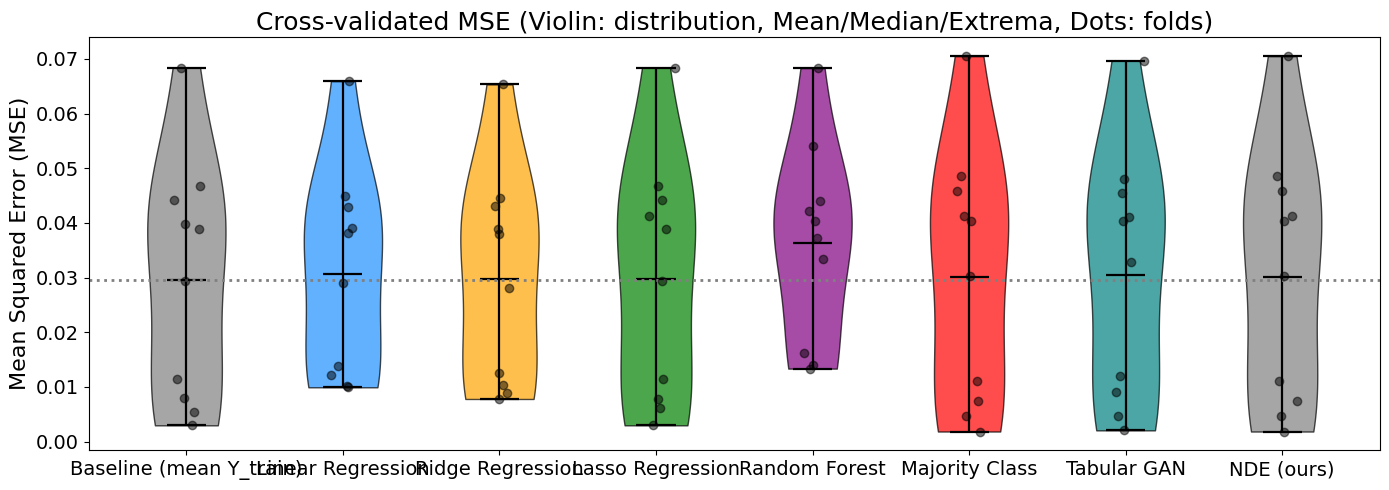

In [29]:
import matplotlib.pyplot as plt

# Set up wider figure
fig, ax = plt.subplots(figsize=(14, 5))

# Update Baseline label for xticks
methods_for_xticks = [m if m != "Baseline" else "Baseline (mean Y_train)" for m in methods]

# ---- Reorder so that Baseline is first ----
# Find the index for Baseline
baseline_idx = methods.index("Baseline")

# Prepare tuples of all data
bars_data = list(zip(
    methods,
    methods_for_xticks,
    means,
    stds,
    mins,
    maxs
))

# Move Baseline to the front
bars_data = [bars_data[baseline_idx]] + bars_data[:baseline_idx] + bars_data[baseline_idx+1:]

# Unpack
ordered_methods, ordered_methods_for_xticks, ordered_means, ordered_stds, ordered_mins, ordered_maxs = zip(*bars_data)

# For NDE and Baseline, adjust the mse_lists
mse_list_map = {}
for m in ordered_methods:
    if m == "NDE (ours)":
        mse_list_map[m] = nde_mses
    elif m == "Baseline":
        mse_list_map[m] = baseline_mses
    else:
        mse_list_map[m] = results[m]["mse_model_list"]

# Collect data for violin plot: Each element is a list of MSEs for each method in order
mse_lists_ordered = [mse_list_map[m] for m in ordered_methods]

# Violin plot
parts = ax.violinplot(
    mse_lists_ordered,
    positions=np.arange(len(ordered_methods_for_xticks)),
    showmeans=True,
    showmedians=False,
    showextrema=True
)

# Custom coloring for violins (optional; can remove for default look)
violin_colors = ['gray', 'dodgerblue', 'orange', 'green', 'purple', 'red', 'teal']
for i, pc in enumerate(parts['bodies']):
    color = violin_colors[i % len(violin_colors)]
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')

for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    vp = parts.get(partname)
    if vp is not None:
        vp.set_edgecolor('black')
        vp.set_linewidth(1.6)

# Jitter scatter points for each method
for i, mse_list in enumerate(mse_lists_ordered):
    xvals = np.random.normal(loc=i, scale=0.05, size=len(mse_list))
    ax.scatter(xvals, mse_list, color='k', alpha=0.5, zorder=10, label='_nolegend_')

# Draw horizontal line at baseline mean
ax.axhline(baseline_means, color='gray', linestyle=':', linewidth=2, label='Baseline Mean')

# Labeling
ax.set_ylabel("Mean Squared Error (MSE)", fontsize=16)
ax.set_title("Cross-validated MSE (Violin: distribution, Mean/Median/Extrema, Dots: folds)", fontsize=18)
ax.set_xticks(np.arange(len(ordered_methods_for_xticks)))
ax.set_xticklabels(ordered_methods_for_xticks, fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend().set_visible(False)
plt.tight_layout()
plt.show()
